# WLS vs Distance Efficiency Comparison
This notebook plots your custom `Positive / Distance` efficiency ratio side-by-side against the traditional WLS metrics (R-Squared, T-Stat, Stability, and Noise).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

# --- CONFIGURATION ---
DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK = 13
ACCEL_LOOKBACK = 3
PLOT_START = '2023-01-01'
PLOT_END = '2023-06-30'
WARMUP_DAYS = 100

In [2]:
# --- MATH FUNCTIONS ---
def calc_wls_full(series, window):
    reg_line_values = np.full(len(series), np.nan)
    slopes = np.full(len(series), np.nan)
    std_errors = np.full(len(series), np.nan) # Noise Size
    r_squared = np.full(len(series), np.nan)
    t_stats = np.full(len(series), np.nan)
    
    x = np.arange(window)
    w = np.arange(1, window + 1)
    sum_w = np.sum(w)
    
    for i in range(window - 1, len(series)):
        y = series.iloc[i - window + 1 : i + 1].values
        
        w_mean_x = np.sum(w * x) / sum_w
        w_mean_y = np.sum(w * y) / sum_w
        
        cov = np.sum(w * (x - w_mean_x) * (y - w_mean_y))
        var_x = np.sum(w * (x - w_mean_x)**2)
        
        slope = cov / var_x if var_x != 0 else 0
        intercept = w_mean_y - slope * w_mean_x
        
        predictions = slope * x + intercept
        residuals = y - predictions
        
        mse = np.sum(w * residuals**2) / sum_w
        se_regression = np.sqrt(mse)
        
        sst = np.sum(w * (y - w_mean_y)**2) / sum_w 
        r2 = max(0, min(1, 1 - (mse / sst))) if sst != 0 else 0
        
        se_slope = se_regression / np.sqrt(var_x) if var_x != 0 else np.inf
        t_stat = slope / se_slope if se_slope != 0 else 0
        
        reg_val = (slope * (window - 1)) + intercept
        reg_line_values[i] = reg_val
        slopes[i] = (slope / w_mean_y) * 252 * 100
        std_errors[i] = (se_regression / w_mean_y) * 100
        r_squared[i] = r2
        t_stats[i] = t_stat
        
    return pd.Series(reg_line_values, index=series.index), \
           pd.Series(slopes, index=series.index), \
           pd.Series(std_errors, index=series.index), \
           pd.Series(r_squared, index=series.index), \
           pd.Series(t_stats, index=series.index)


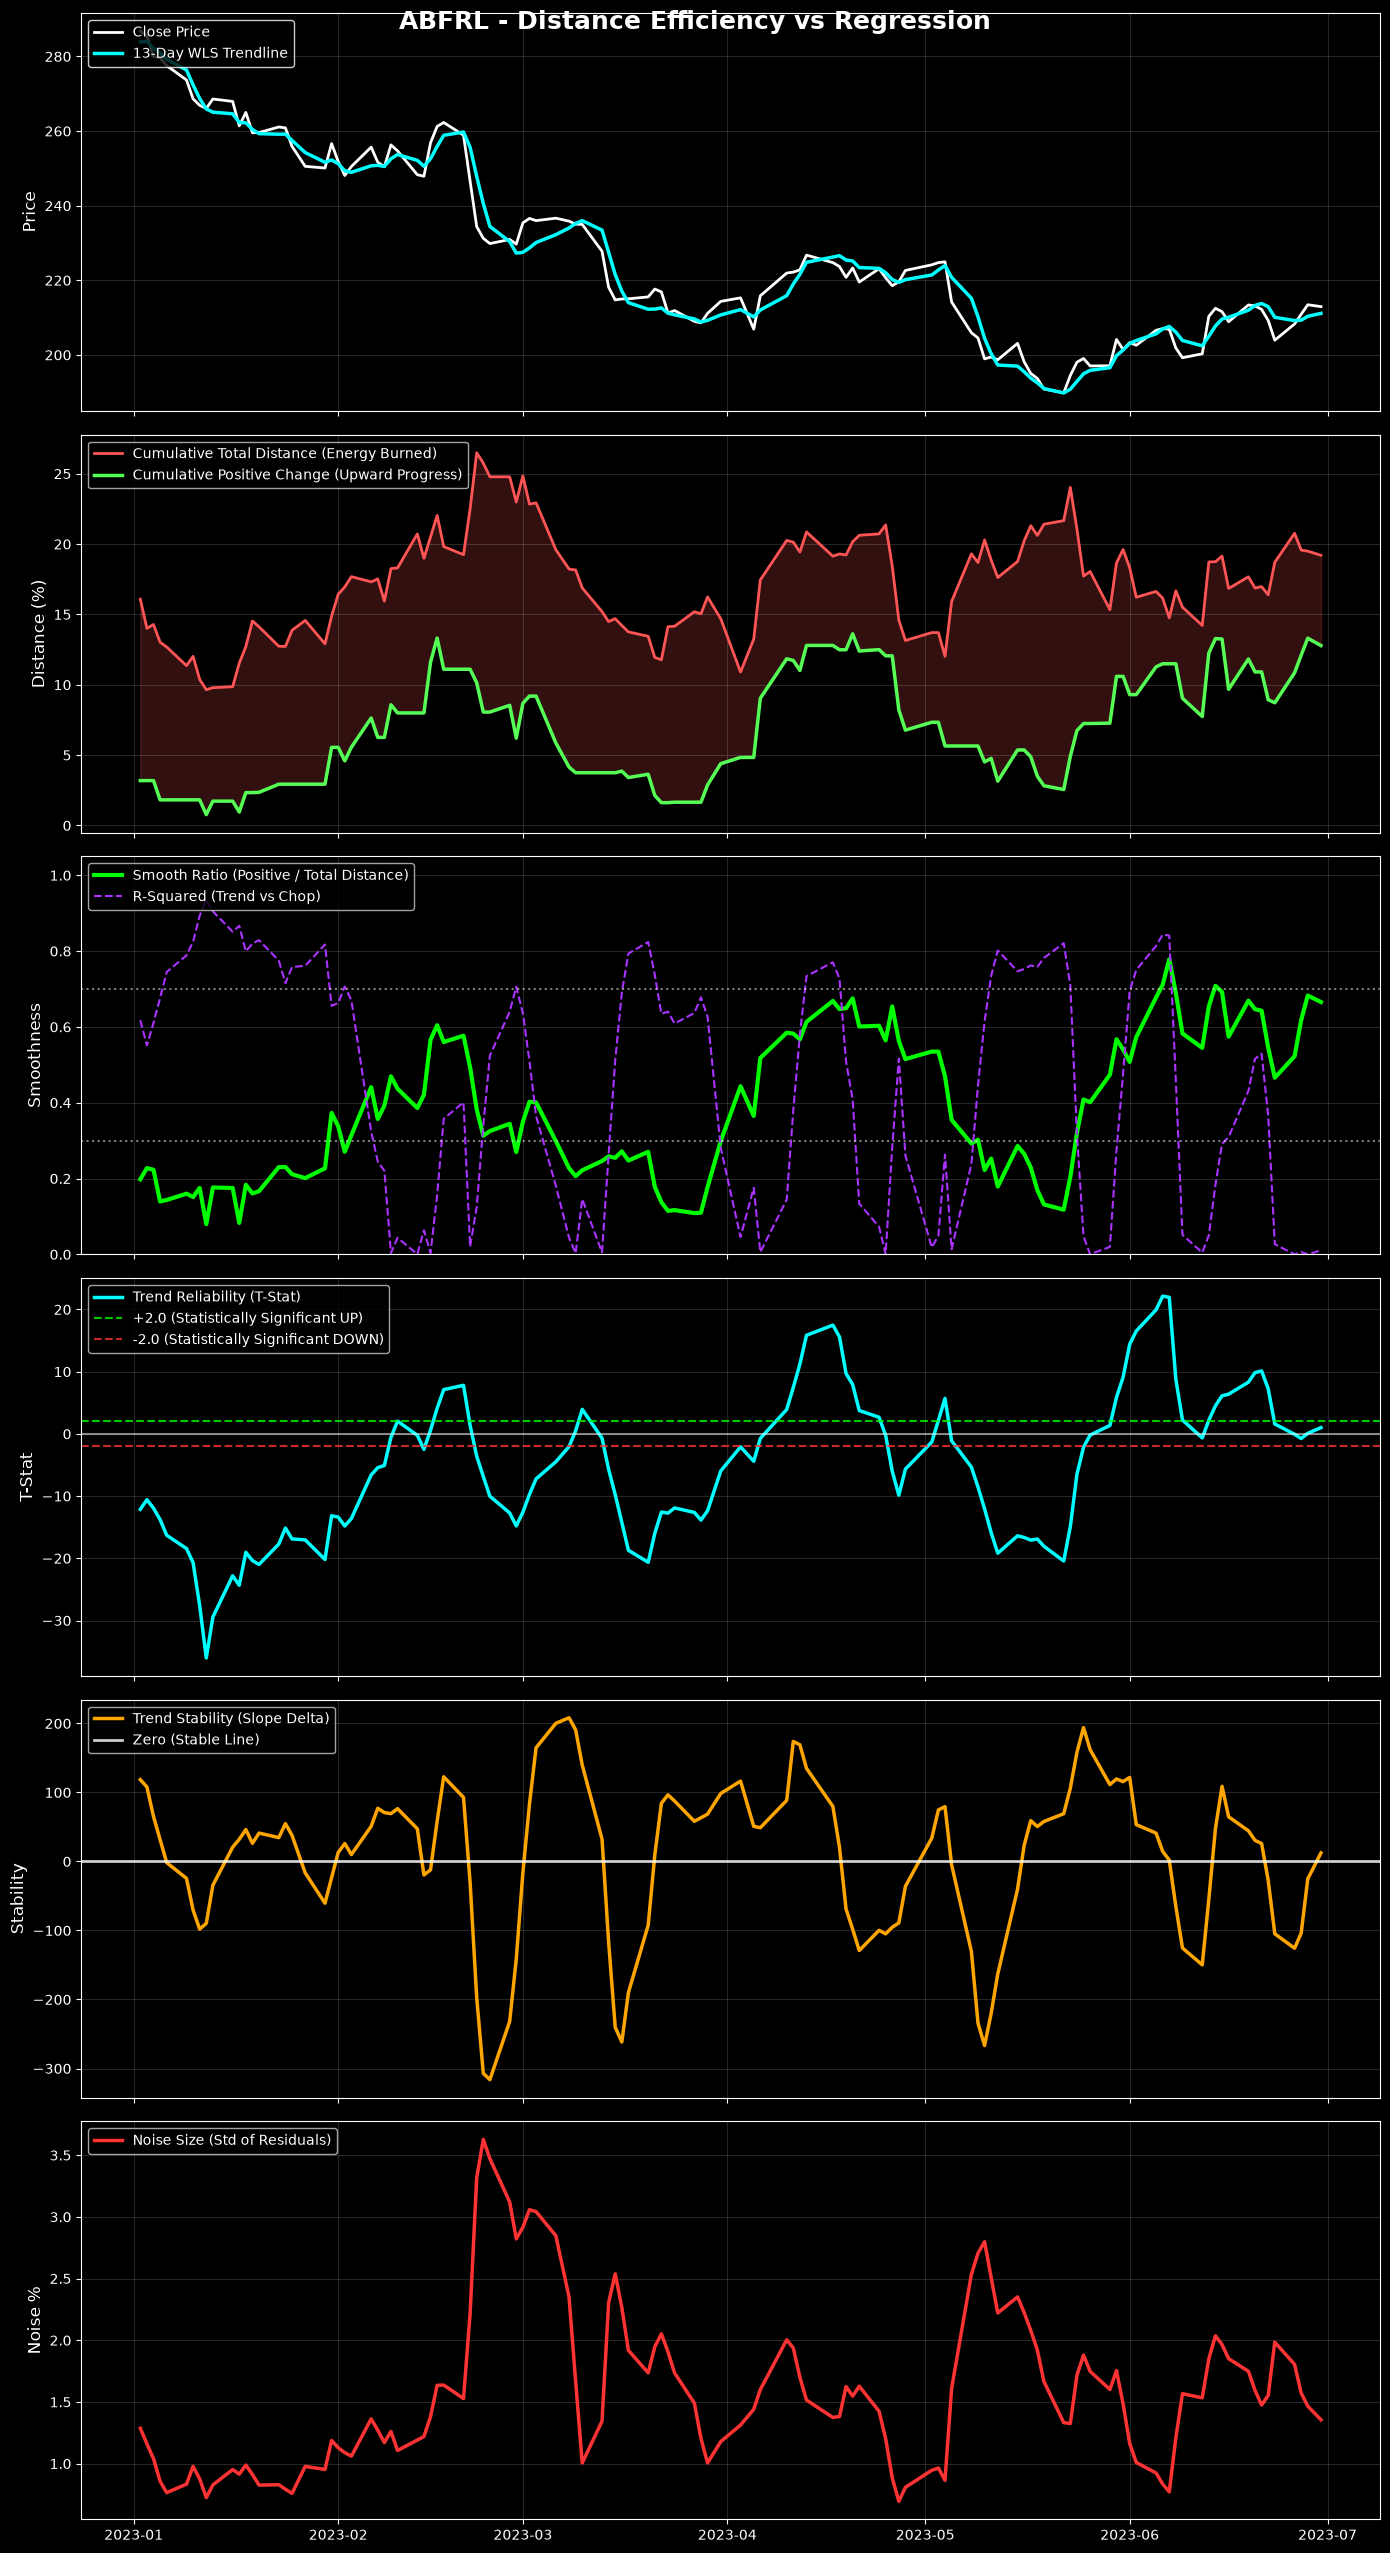

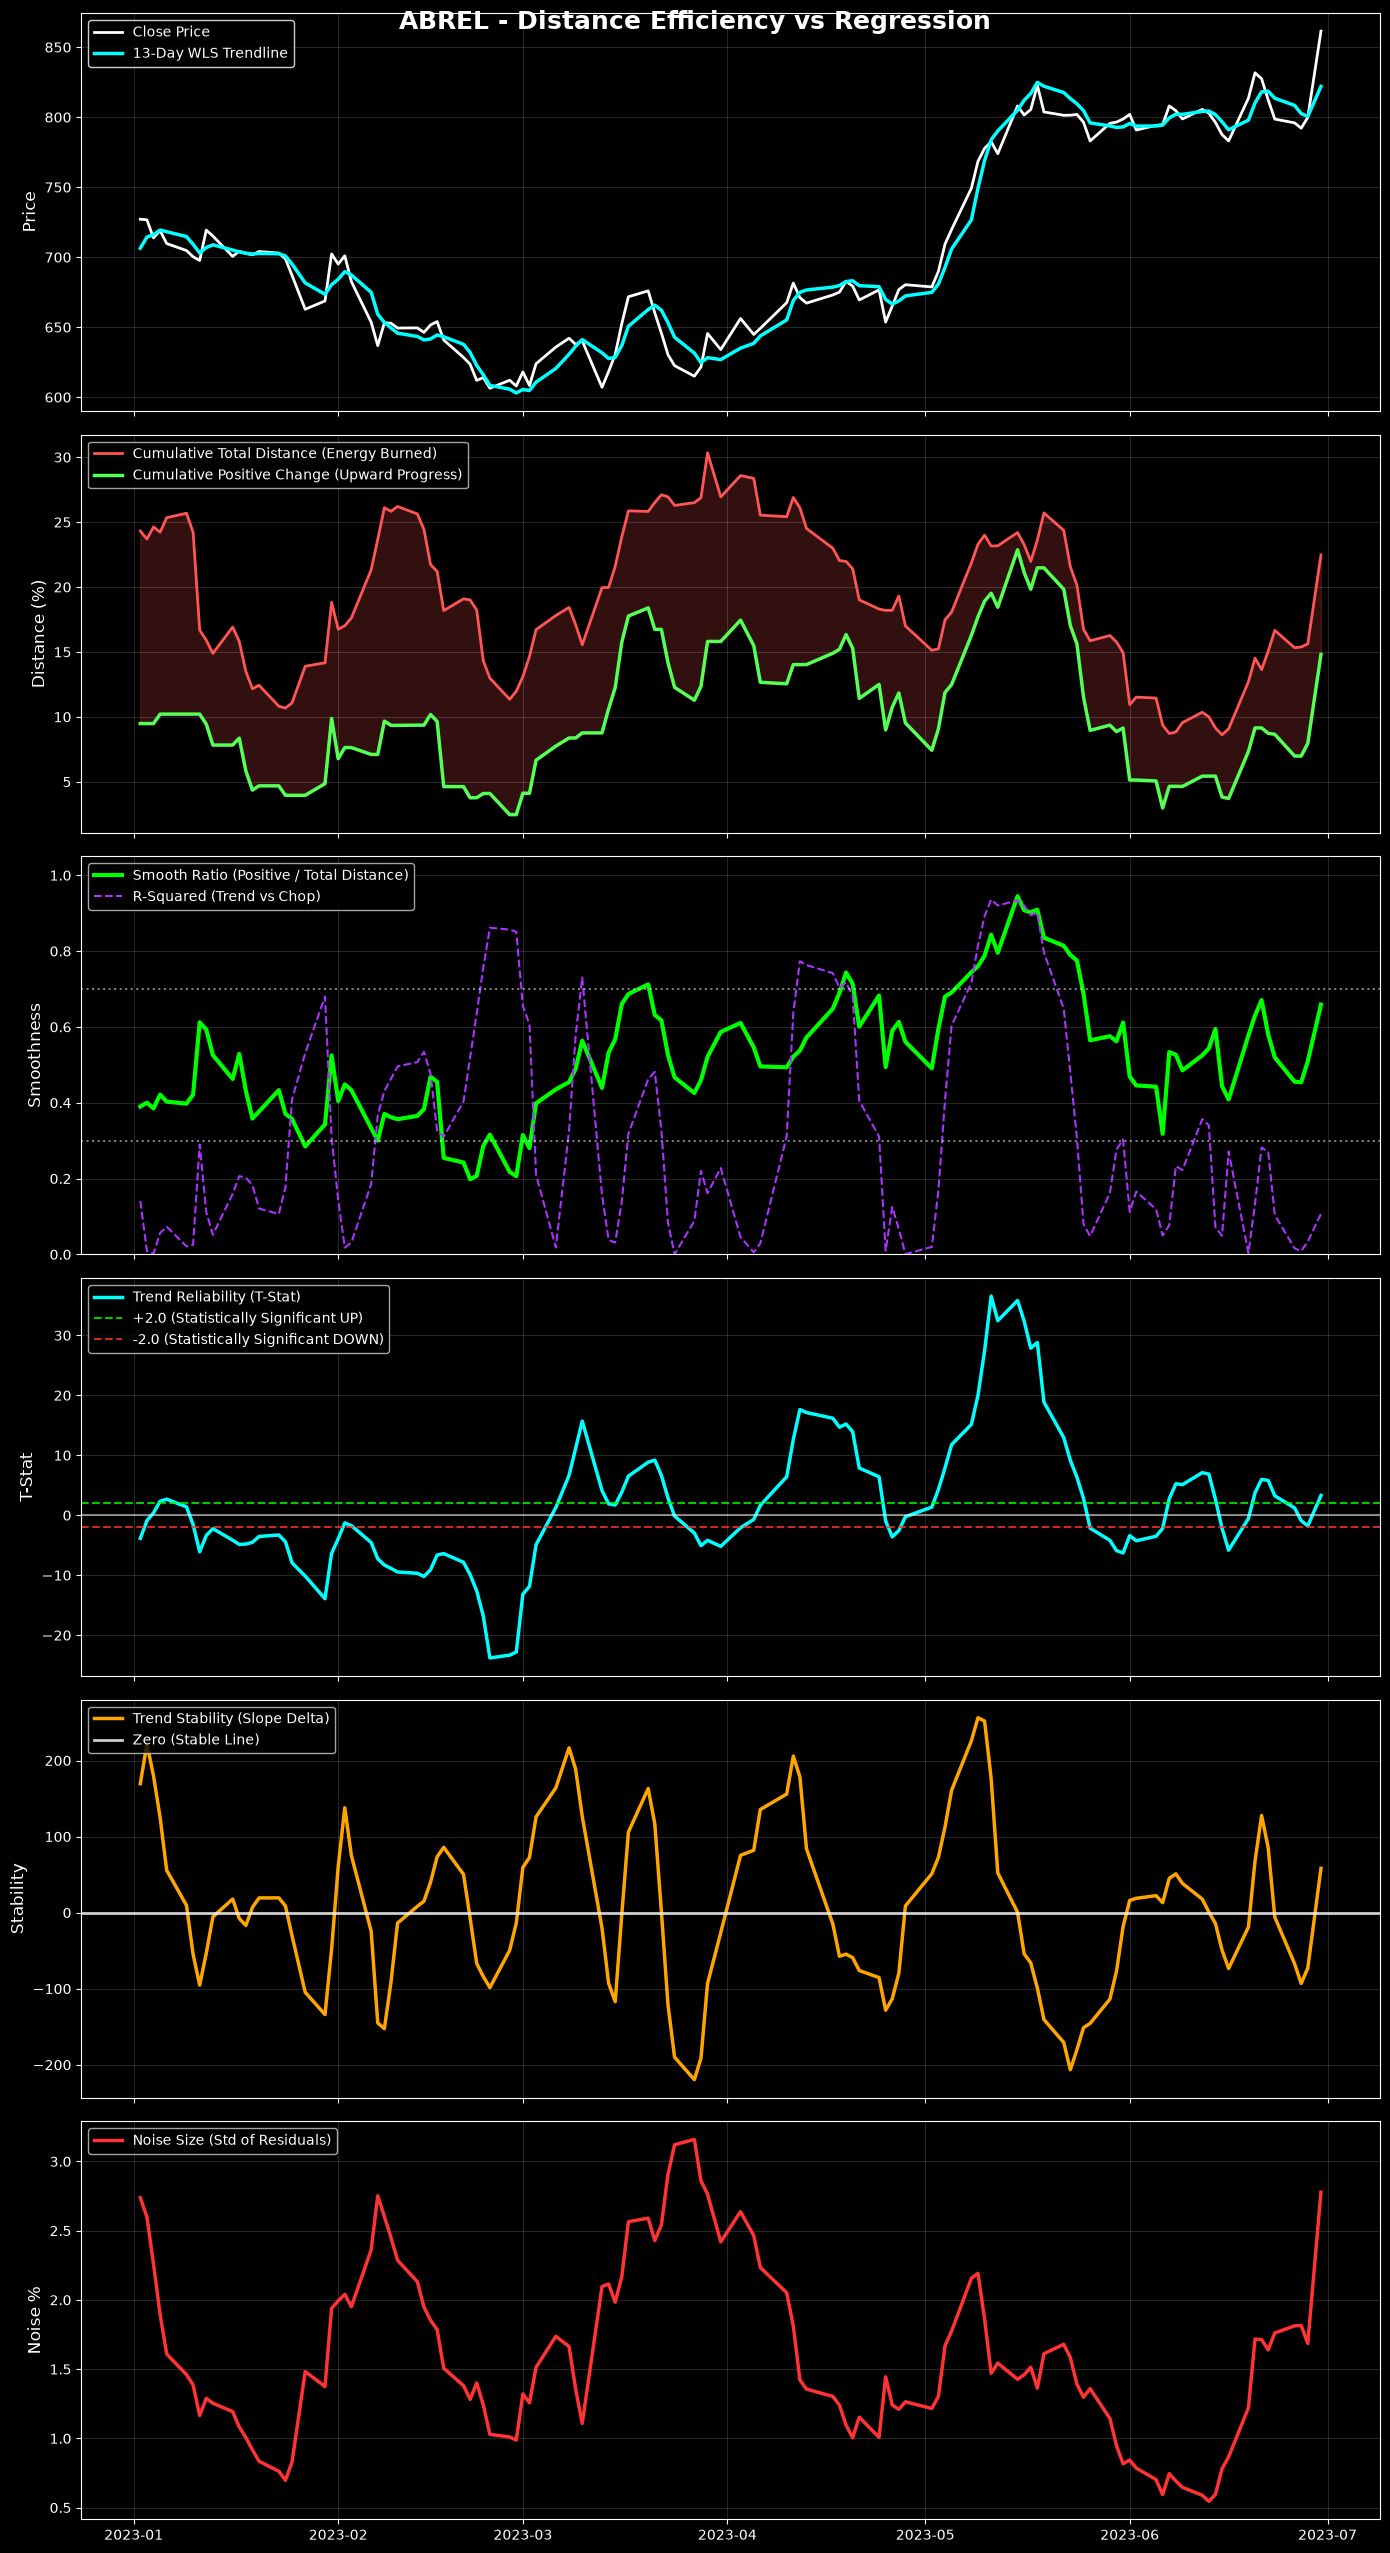

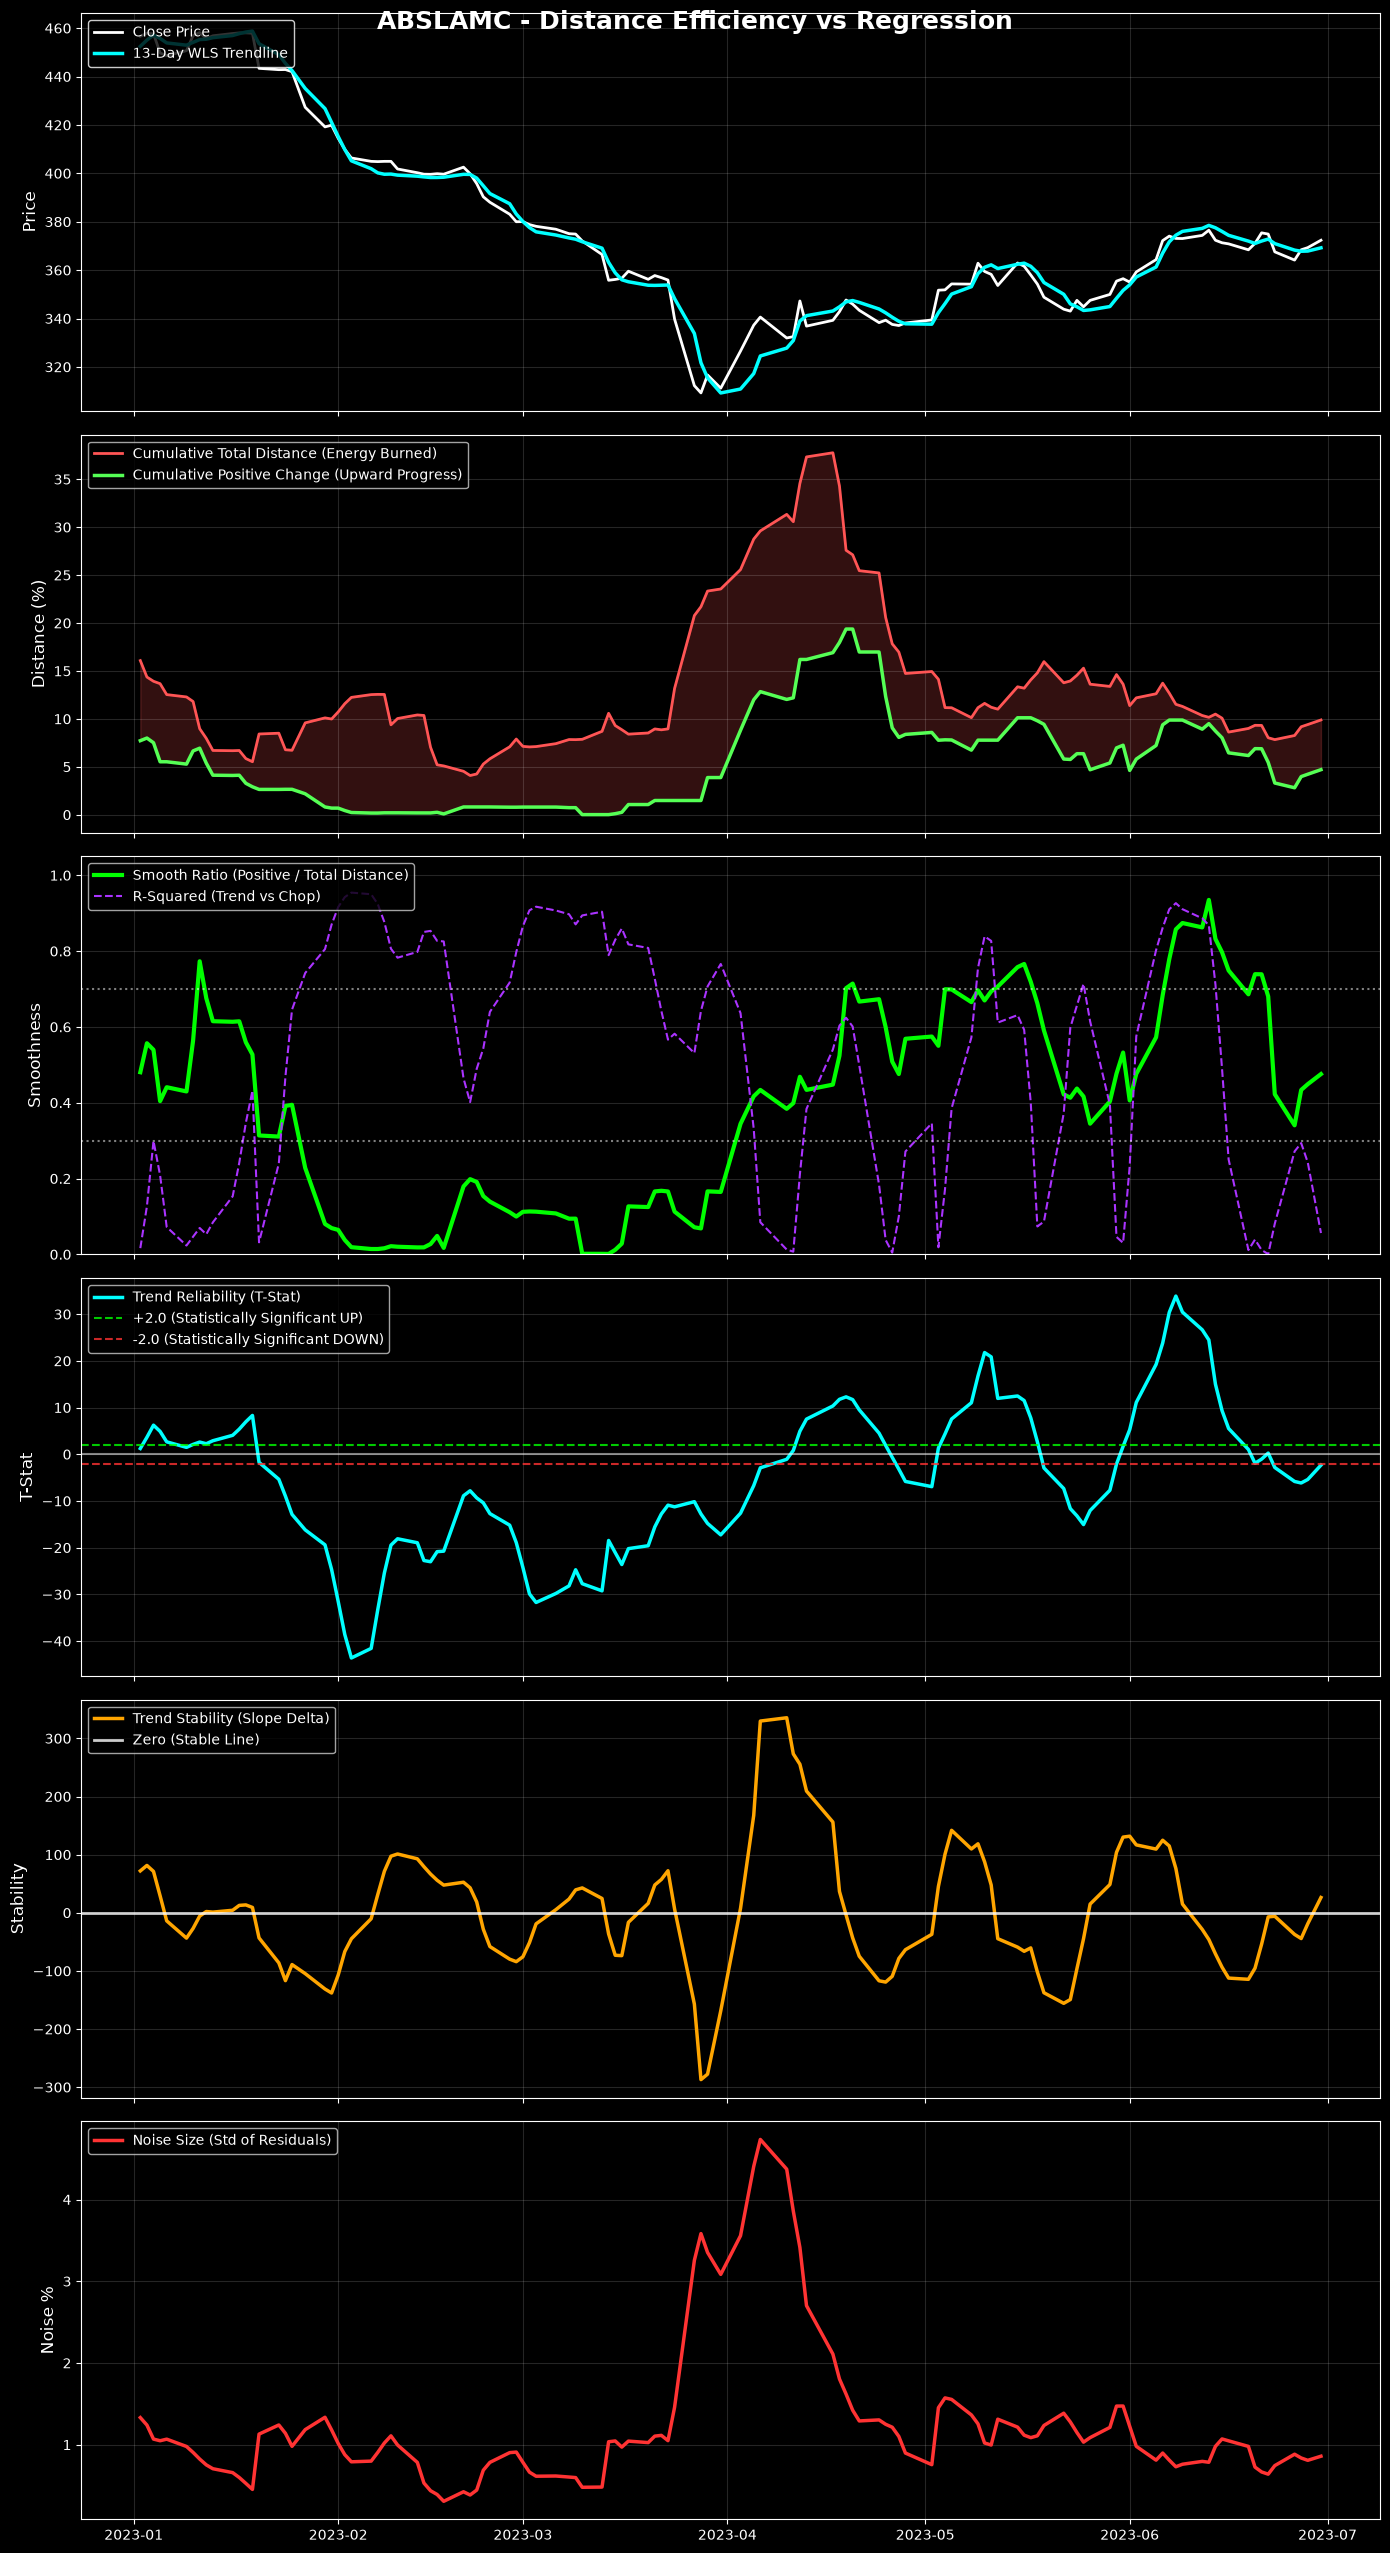

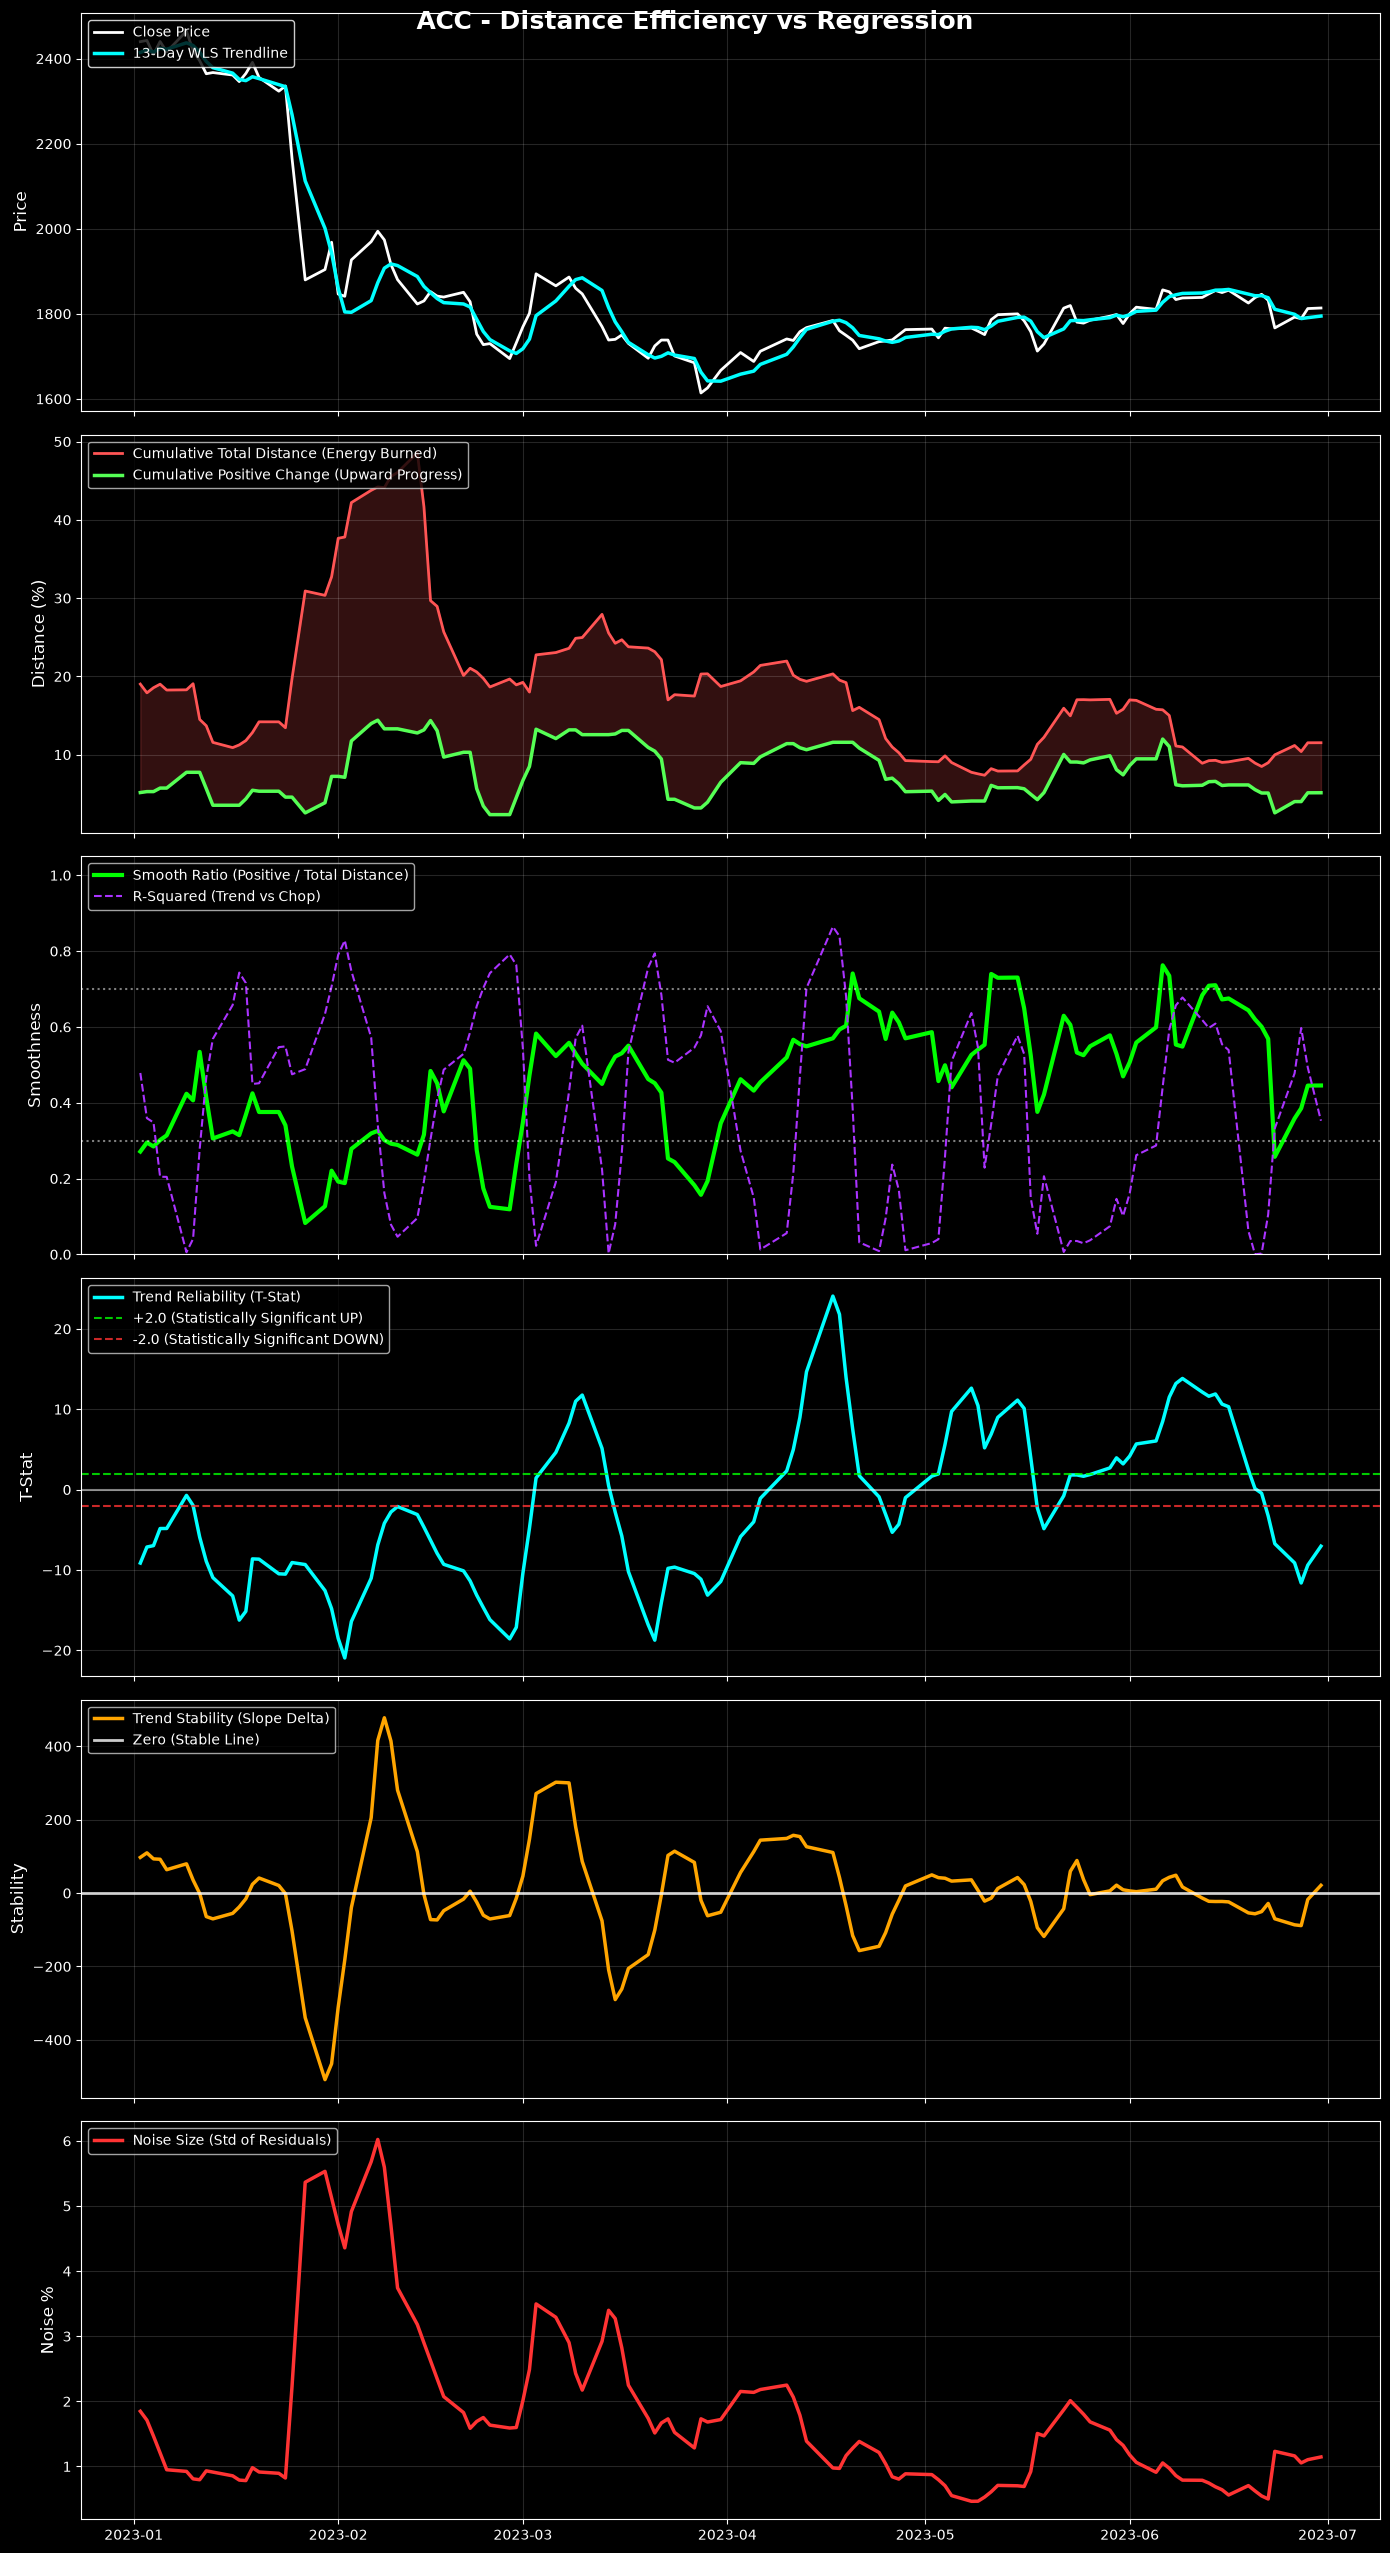

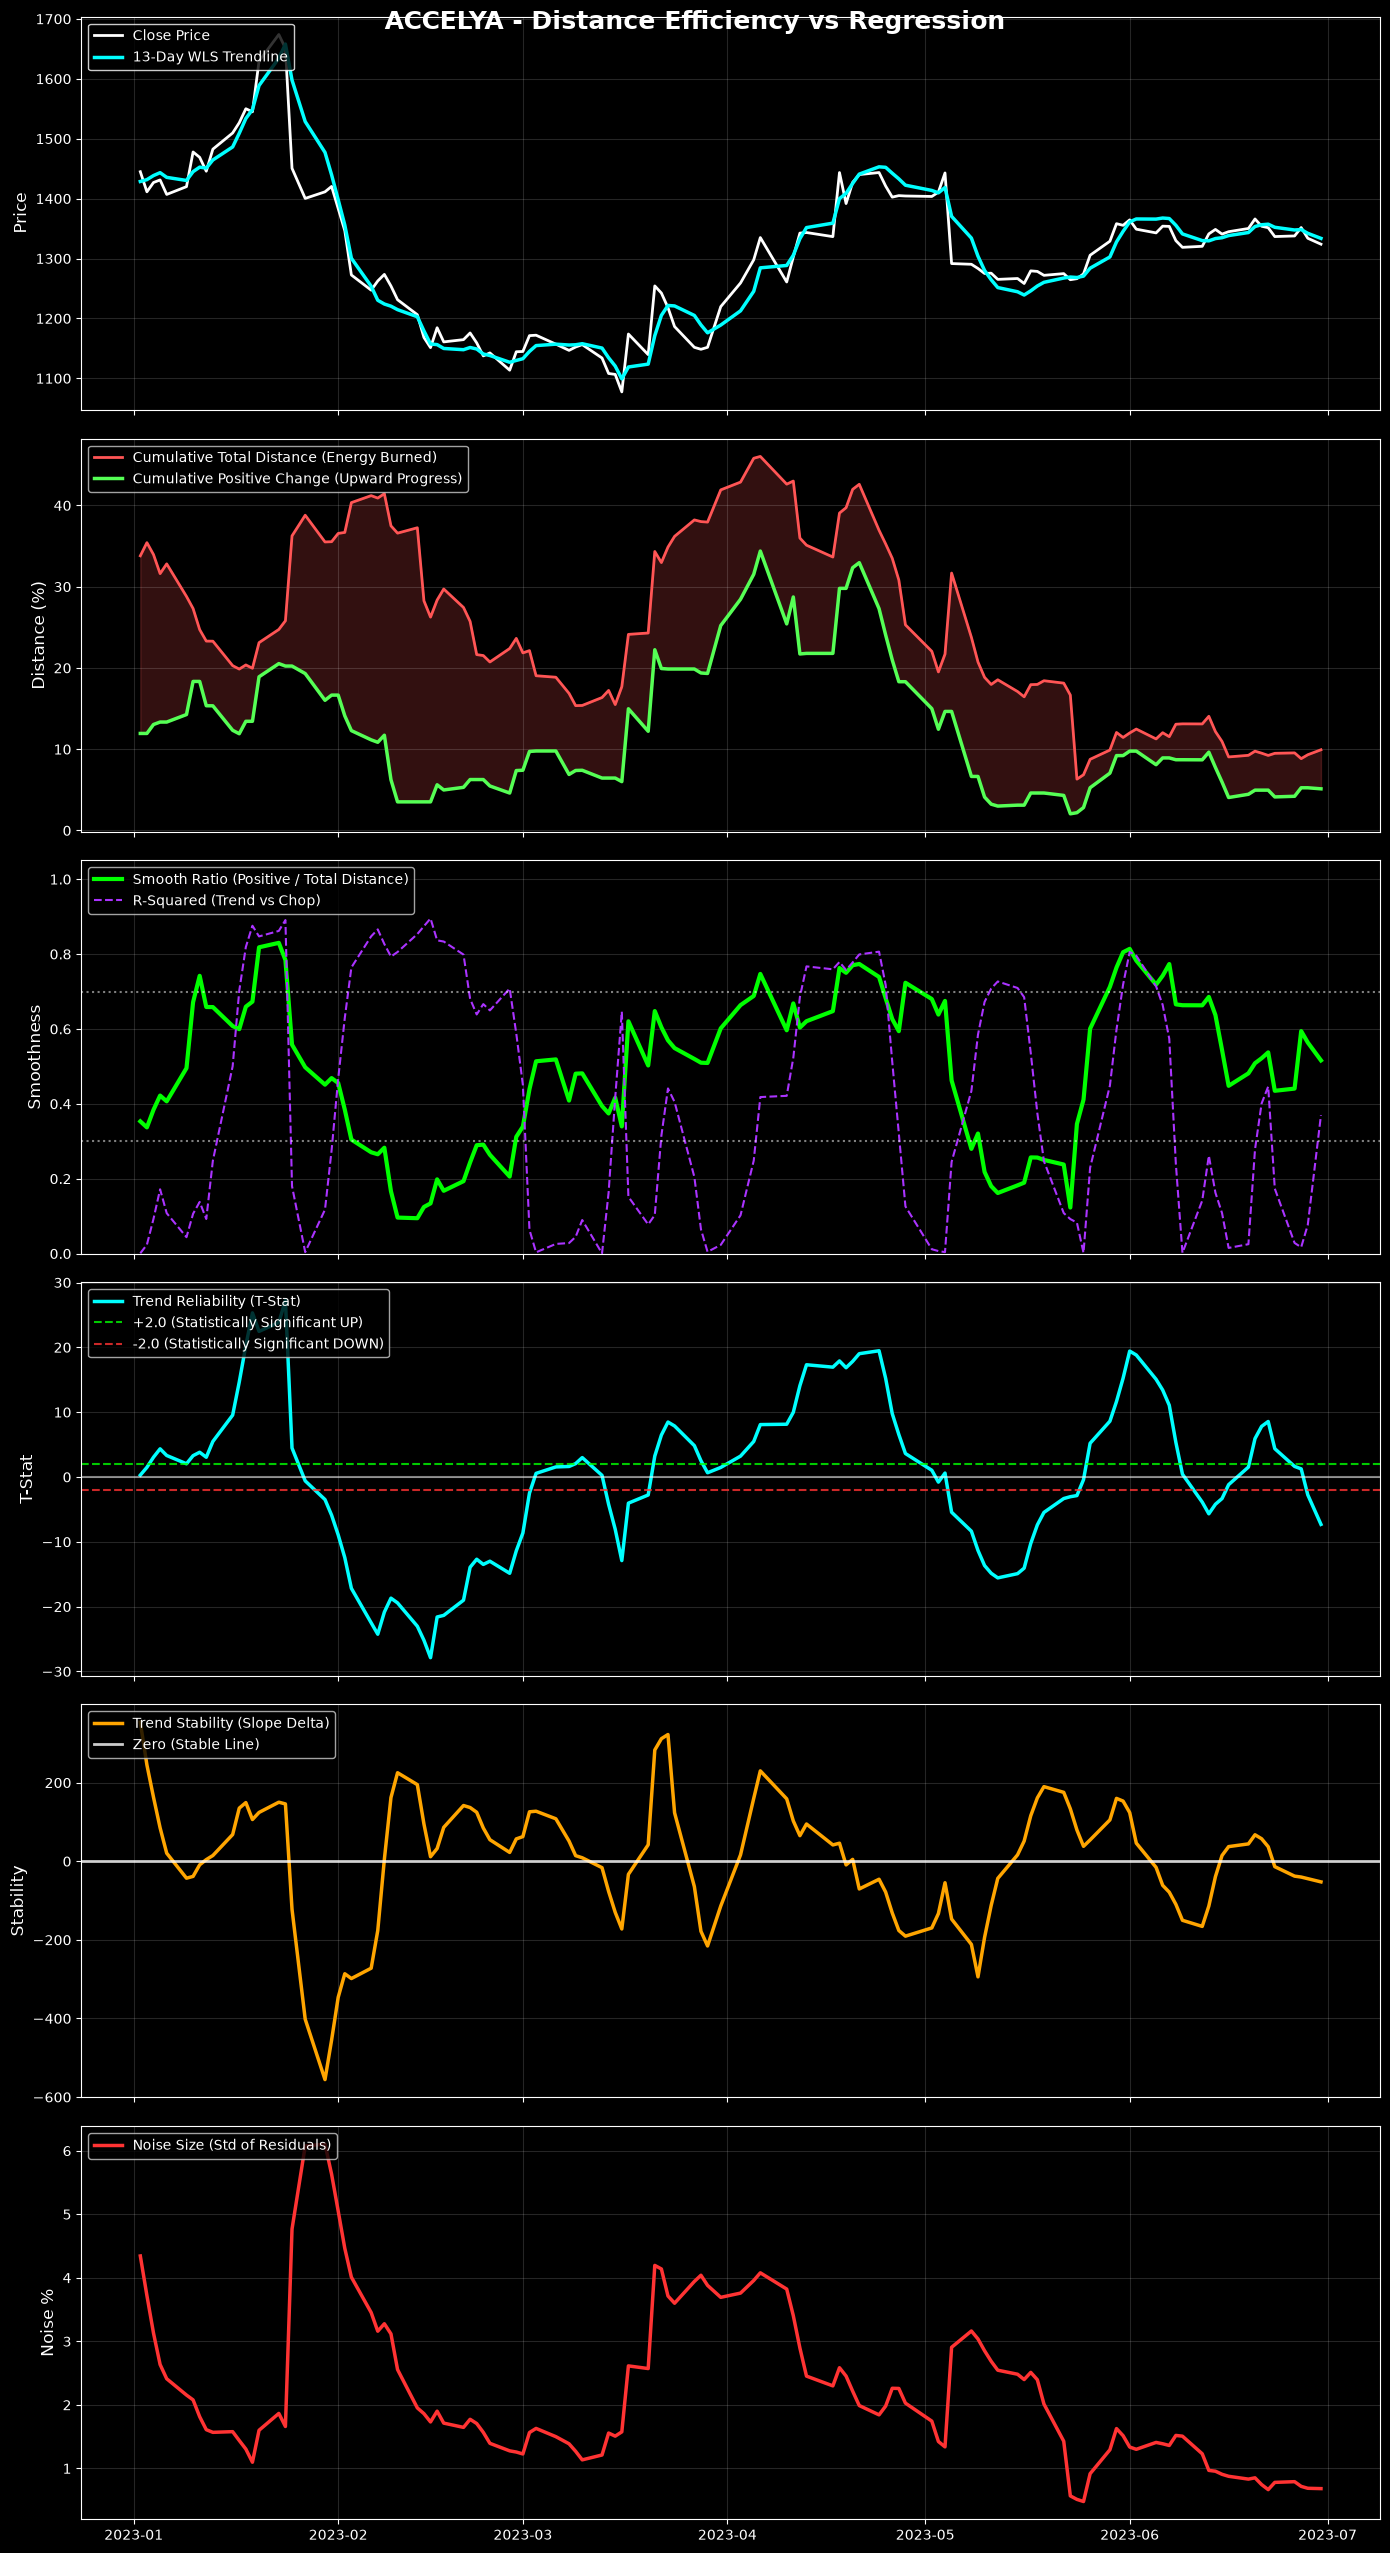

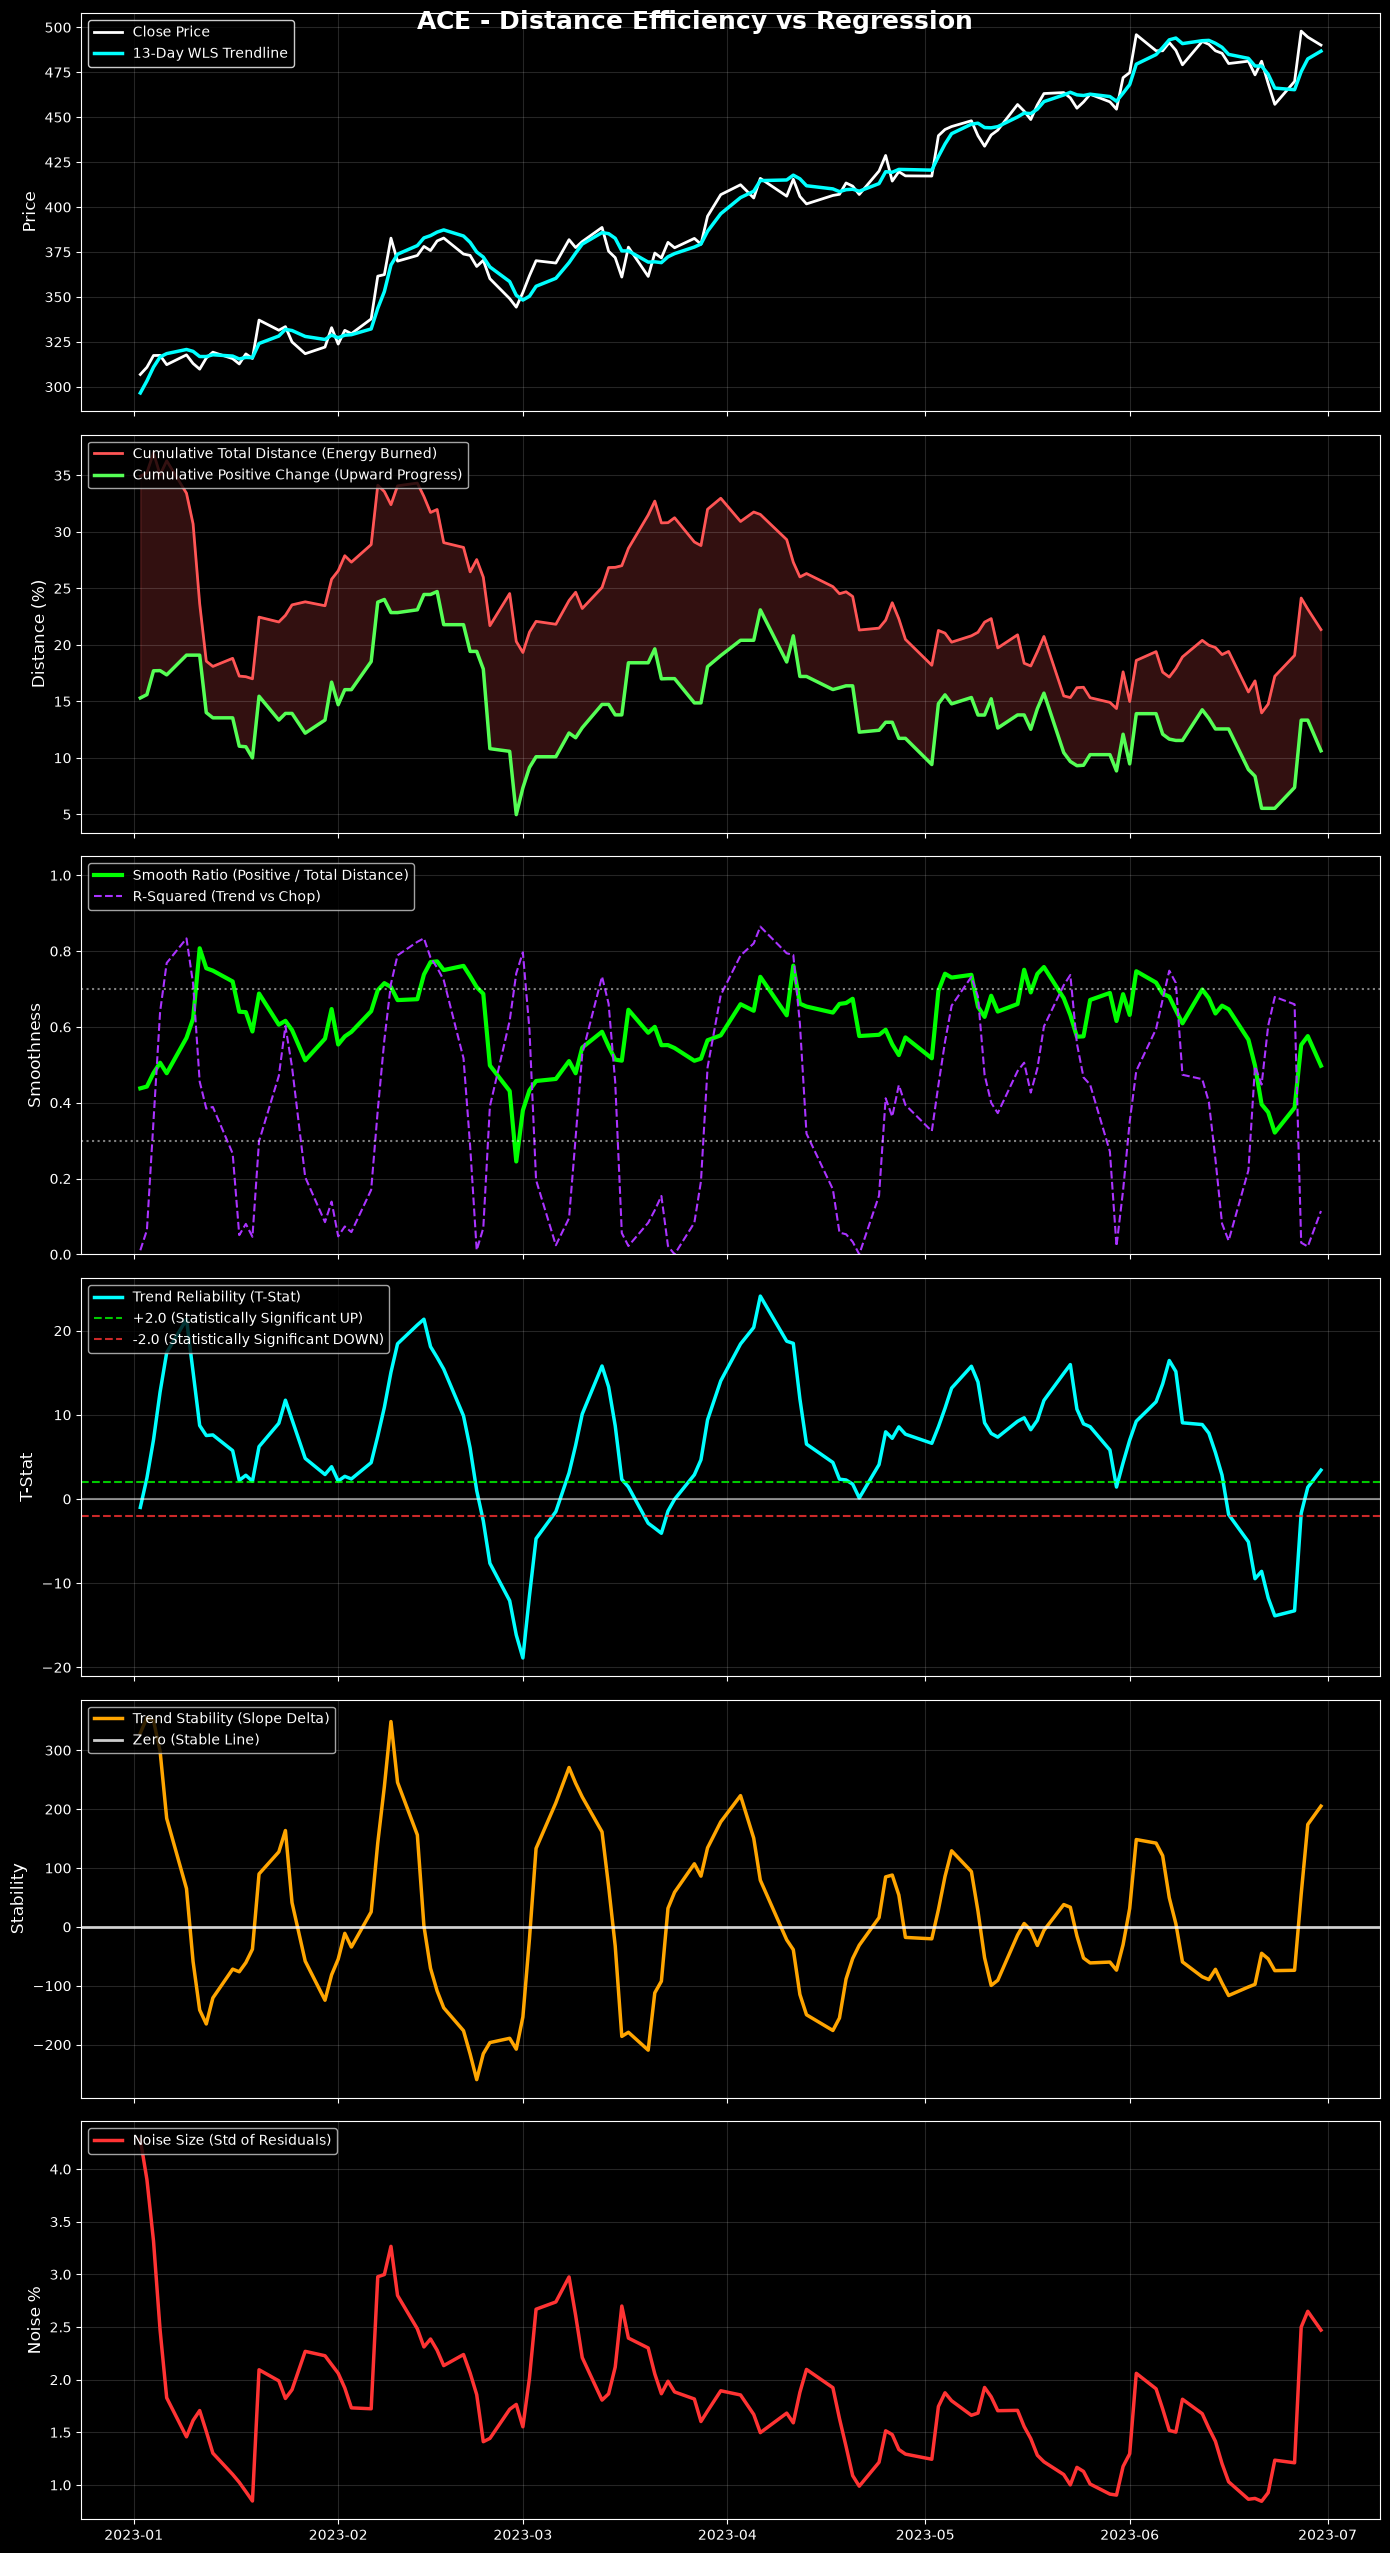

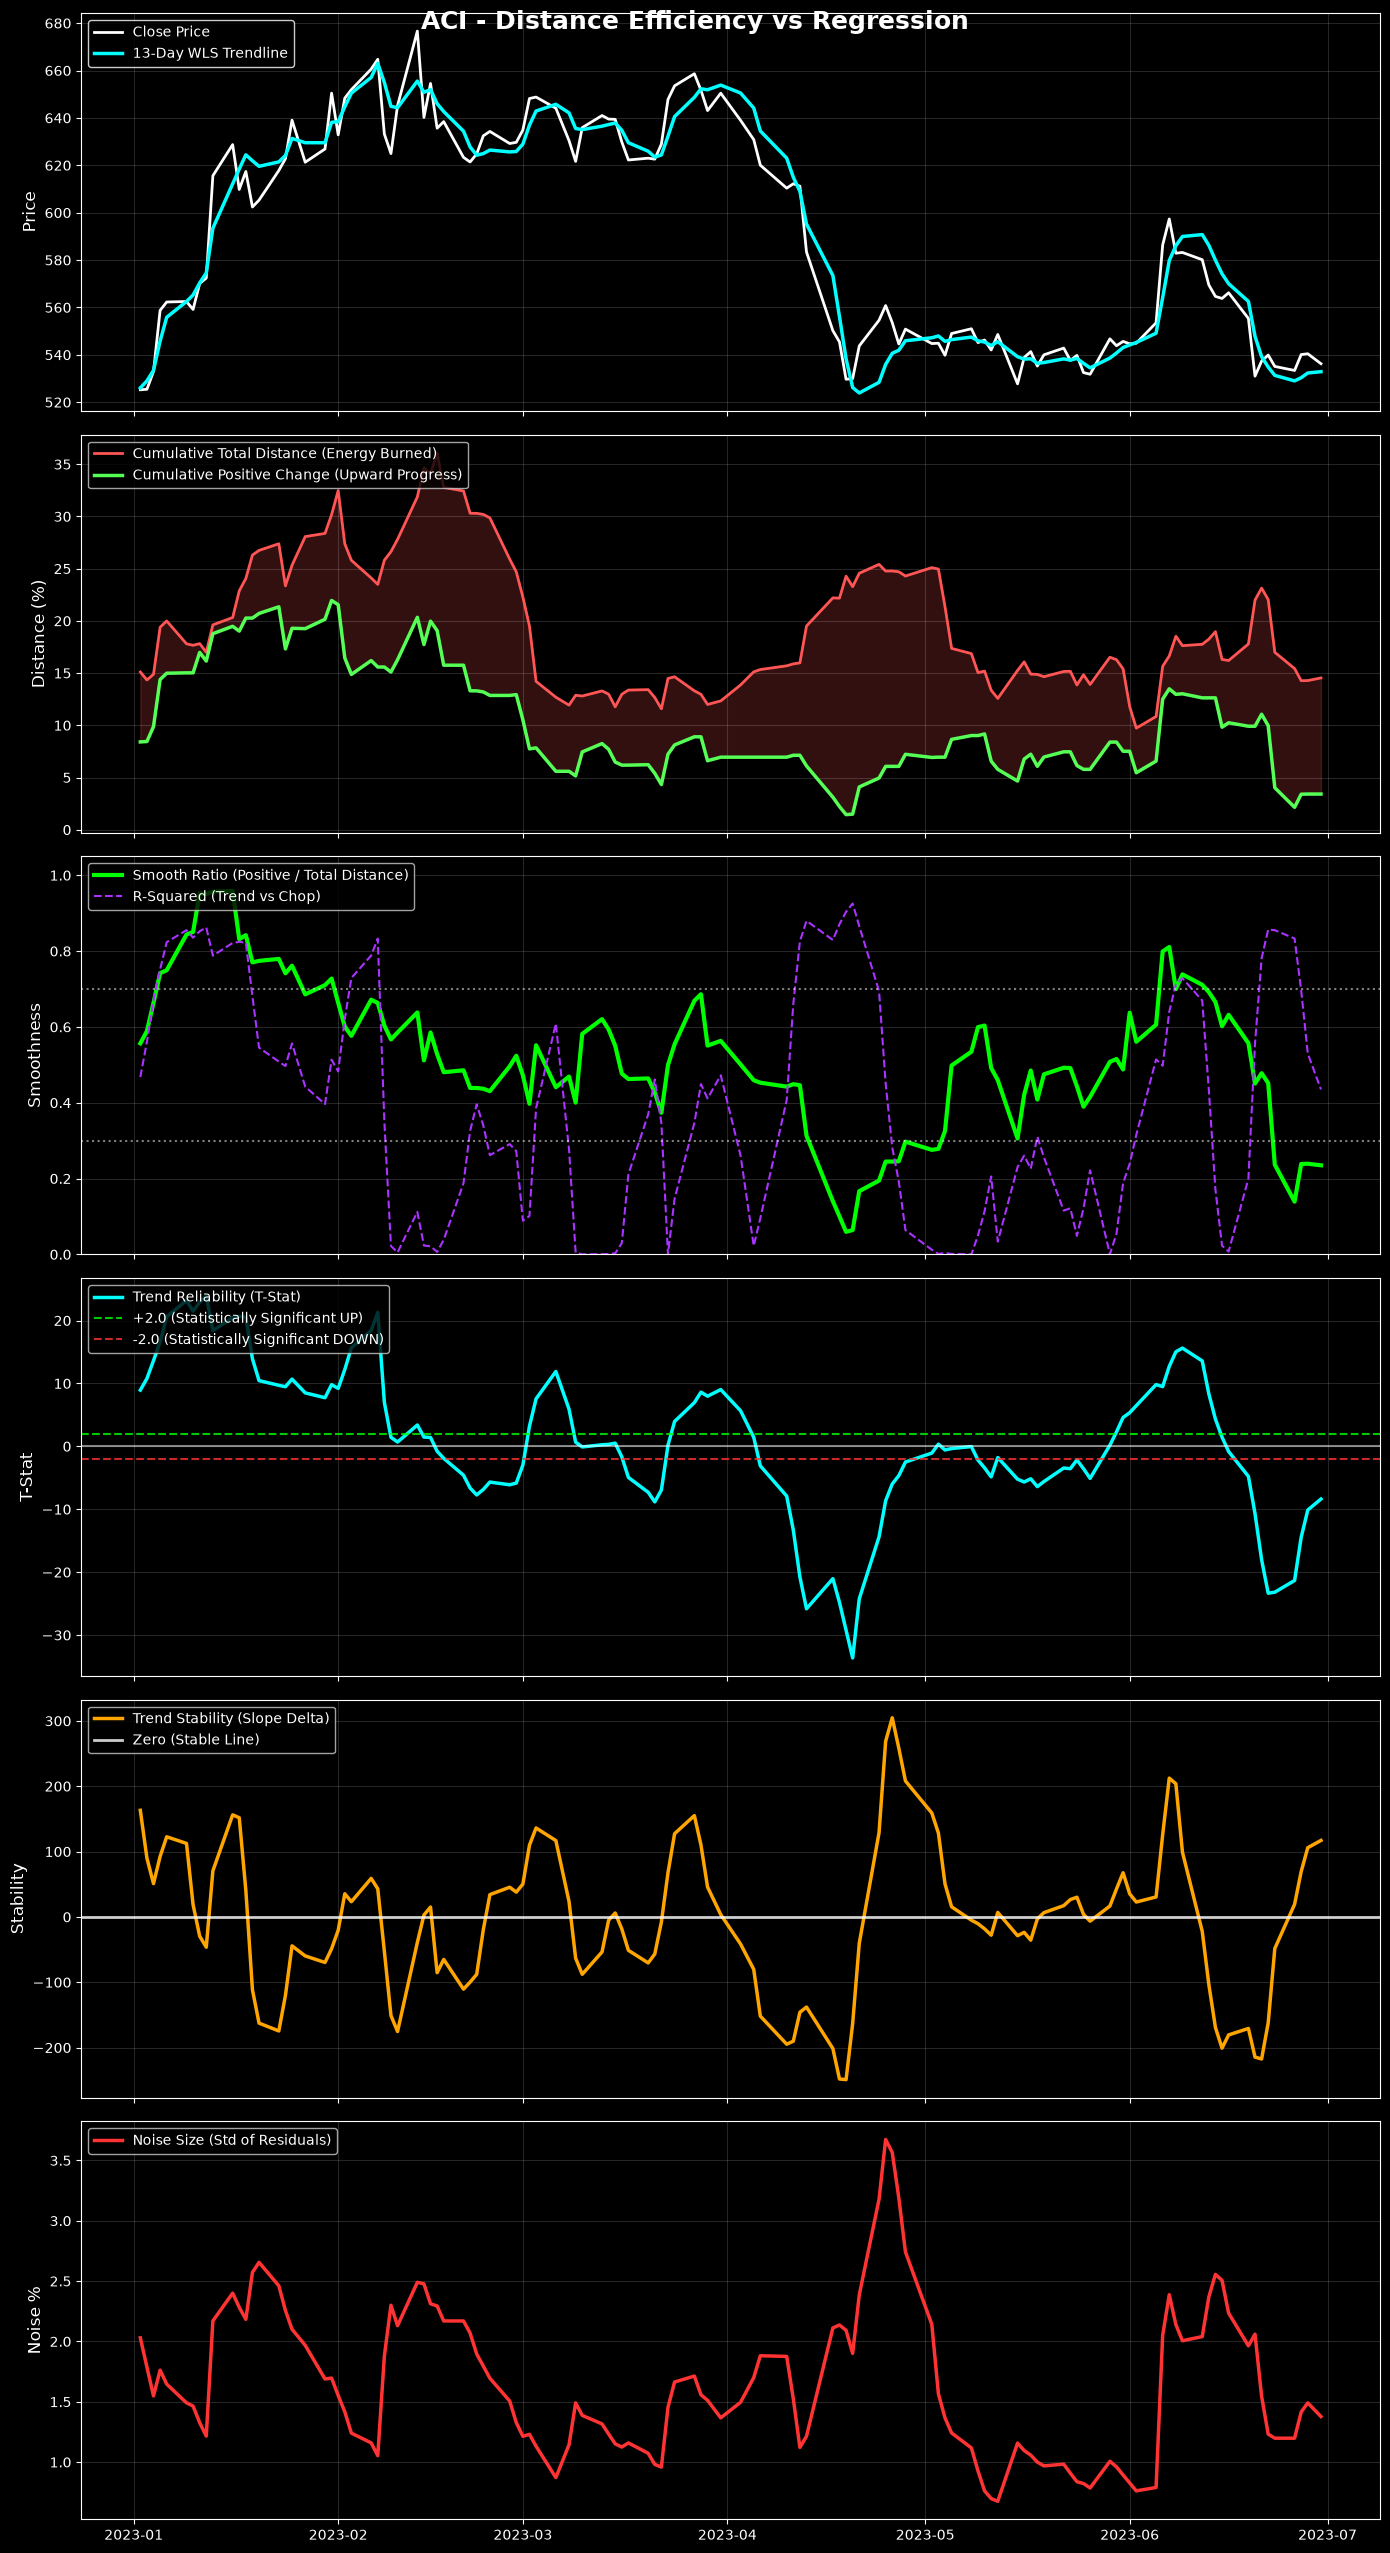

In [3]:
# --- PROCESSING & PLOTTING ---
all_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))[10:20]

for file in all_files:
    stock_name = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    try:
        start_idx = df[df['Date'] >= PLOT_START].index[0]
        load_start_idx = max(0, start_idx - WARMUP_DAYS)
        end_idx = df[df['Date'] <= PLOT_END].index[-1]
    except IndexError:
        continue 
        
    df = df.iloc[load_start_idx:end_idx+1].copy()
    
    # 1. Distance & Efficiency Math
    df['pct_change'] = df['Close'].pct_change() * 100
    df['abs_change'] = df['pct_change'].abs()
    df['pos_change'] = np.where(df['pct_change'] > 0, df['pct_change'], 0)
    
    df['roll_distance'] = df['abs_change'].rolling(LOOKBACK).sum()
    df['roll_positive'] = df['pos_change'].rolling(LOOKBACK).sum()
    df['smooth_ratio'] = df['roll_positive'] / df['roll_distance']
    
    # 2. WLS Math
    df['lr_13'], df['slope_13'], df['se_13'], df['r2_13'], df['t_stat_13'] = calc_wls_full(df['Close'], LOOKBACK)
    df['stability_13'] = df['slope_13'].diff(ACCEL_LOOKBACK)
    
    # Trim Warmup
    plot_df = df[df['Date'] >= PLOT_START].copy()
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(6, 1, figsize=(14, 26), sharex=True)
    fig.suptitle(f"{stock_name} - Distance Efficiency vs Regression", fontsize=18, weight='bold', color='white')
    
    # Pane 1: Price and Regressions
    axes[0].plot(plot_df['Date'], plot_df['Close'], color='#FFFFFF', linewidth=2, label='Close Price')
    axes[0].plot(plot_df['Date'], plot_df['lr_13'], color='#00FFFF', linewidth=2.5, label='13-Day WLS Trendline')
    axes[0].set_ylabel("Price", fontsize=12)
    axes[0].legend(loc='upper left', frameon=True, facecolor='black', edgecolor='white')
    axes[0].grid(color='white', alpha=0.15)
    
    # Pane 2: Distance Travelled vs Positive Change
    axes[1].plot(plot_df['Date'], plot_df['roll_distance'], color='#FF5555', linewidth=2, label='Cumulative Total Distance (Energy Burned)')
    axes[1].plot(plot_df['Date'], plot_df['roll_positive'], color='#55FF55', linewidth=2.5, label='Cumulative Positive Change (Upward Progress)')
    axes[1].fill_between(plot_df['Date'], plot_df['roll_positive'], plot_df['roll_distance'], color='#FF5555', alpha=0.2)
    axes[1].set_ylabel("Distance (%)", fontsize=12)
    axes[1].legend(loc='upper left', frameon=True, facecolor='black')
    axes[1].grid(color='white', alpha=0.15)
    
    # Pane 3: The Smooth Ratio vs R-Squared (HEAD TO HEAD)
    axes[2].plot(plot_df['Date'], plot_df['smooth_ratio'], color='#00FF00', linewidth=3, label='Smooth Ratio (Positive / Total Distance)')
    axes[2].plot(plot_df['Date'], plot_df['r2_13'], color='#AA33FF', linewidth=1.5, linestyle='--', label='R-Squared (Trend vs Chop)')
    axes[2].axhline(0.7, color='white', linestyle=':', alpha=0.5)
    axes[2].axhline(0.3, color='white', linestyle=':', alpha=0.5)
    axes[2].set_ylabel("Smoothness", fontsize=12)
    axes[2].set_ylim(0, 1.05)
    axes[2].legend(loc='upper left', frameon=True, facecolor='black')
    axes[2].grid(color='white', alpha=0.15)
    
    # Pane 4: Trend Reliability (T-Stat)
    axes[3].plot(plot_df['Date'], plot_df['t_stat_13'], color='#00FFFF', linewidth=2.5, label='Trend Reliability (T-Stat)')
    axes[3].axhline(2.0, color='#00FF00', linestyle='--', linewidth=1.5, alpha=0.8, label='+2.0 (Statistically Significant UP)')
    axes[3].axhline(-2.0, color='#FF3333', linestyle='--', linewidth=1.5, alpha=0.8, label='-2.0 (Statistically Significant DOWN)')
    axes[3].axhline(0, color='white', linestyle='-', linewidth=1.5, alpha=0.5)
    axes[3].set_ylabel("T-Stat", fontsize=12)
    axes[3].legend(loc='upper left', frameon=True, facecolor='black')
    axes[3].grid(color='white', alpha=0.15)
    
    # Pane 5: Trend Stability (Rolling change in Slope)
    axes[4].plot(plot_df['Date'], plot_df['stability_13'], color='#FFA500', linewidth=2.5, label='Trend Stability (Slope Delta)')
    axes[4].axhline(0, color='white', linestyle='-', linewidth=2, alpha=0.8, label='Zero (Stable Line)')
    axes[4].set_ylabel("Stability", fontsize=12)
    axes[4].legend(loc='upper left', frameon=True, facecolor='black')
    axes[4].grid(color='white', alpha=0.15)
    
    # Pane 6: Noise Size (Std of Residual)
    axes[5].plot(plot_df['Date'], plot_df['se_13'], color='#FF3333', linewidth=2.5, label='Noise Size (Std of Residuals)')
    axes[5].set_ylabel("Noise %", fontsize=12)
    axes[5].legend(loc='upper left', frameon=True, facecolor='black')
    axes[5].grid(color='white', alpha=0.15)
    
    plt.tight_layout()
    plt.show()
